# Structural Analysis of the DD Dataset

This notebook performs a structural analysis of the DD (D&D) dataset.  

The DD dataset consists of multiple large graphs representing protein structures, where nodes correspond to amino acids and edges encode spatial proximity.

Since the dataset contains many graphs rather than a single global structure, structural statistics are computed per graph and then aggregated across the dataset.

These diagnostics aim to identify potential structural bottlenecks and long-range dependencies that may impact message passing, making DD particularly relevant for analyzing depth-related issues such as over-squashing.

In [1]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx, degree
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.loader import DataLoader

from torch.utils.data import random_split

import networkx as nx

c:\Master\GAI\gnn-over-squashing-cora\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("../../results/plots/dd", exist_ok=True)
os.makedirs("../../results/tables/dd", exist_ok=True)

## Dataset

The experiments are conducted on the DD dataset

In [3]:
dataset = TUDataset(root="../../data", name="DD")

print(dataset)
print("Number of graphs:", len(dataset))
print("Num node features:", dataset.num_features)
print("Num classes:", dataset.num_classes)

DD(1178)
Number of graphs: 1178
Num node features: 89
Num classes: 2


## Models

In [4]:
sys.path.append(os.path.abspath("../.."))

from src.models.graph_classification import GCN, GraphSAGE, GAT

from src.training.train import train_graph_classification
from src.training.evaluate import evaluate_graph_classification

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 64
epochs = 200
lr = 0.001
weight_decay = 0.0005
dropout = 0.5

layer_values = [2, 4, 6, 8]
seeds = [0, 7, 37, 42]

results = {m: {"layers": [], "acc_mean": [], "acc_std": [], "time": []} for m in models.keys()}
history = {}

num_graphs = len(dataset)
train_size = int(0.8 * num_graphs)
val_size = int(0.1 * num_graphs)
test_size = num_graphs - train_size - val_size

batch_size = 32

for model_name, Model in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    history[model_name] = {}

    for num_layers in layer_values:
        history[model_name][num_layers] = {}

        acc_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            split_generator = torch.Generator().manual_seed(seed)

            train_dataset, val_dataset, test_dataset = random_split(
                dataset,
                [train_size, val_size, test_size],
                generator=split_generator
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True,
                generator=torch.Generator().manual_seed(seed)
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=batch_size,
                shuffle=False
            )

            test_loader = DataLoader(
                test_dataset,
                batch_size=batch_size,
                shuffle=False
            )

            model = Model(in_dim, hidden_dim, num_classes, num_layers, dropout).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            start = time.time()

            hist = train_graph_classification(
                model,
                train_loader,
                val_loader,
                optimizer,
                epochs=epochs,
                device=device
            )
            history[model_name][num_layers][seed] = hist

            elapsed = time.time() - start

            acc = evaluate_graph_classification(
                model,
                test_loader,
                device=device
            )

            acc_runs.append(acc)
            time_runs.append(elapsed)

        # estadísticas
        acc_mean = np.mean(acc_runs)
        acc_std = np.std(acc_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["acc_mean"].append(acc_mean)
        results[model_name]["acc_std"].append(acc_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}"
        )

Running on cuda

Running experiments for GCN


100%|██████████| 200/200 [01:04<00:00,  3.09it/s]


Layers: 2 | Accuracy: 0.7059 ± 0.0281


100%|██████████| 200/200 [01:35<00:00,  2.09it/s]


Layers: 4 | Accuracy: 0.7059 ± 0.0457


...

Layers: 4 | Accuracy: 0.6992 ± 0.0423


100%|██████████| 200/200 [07:33<00:00,  2.27s/it]


Layers: 6 | Accuracy: 0.6891 ± 0.0472


100%|██████████| 200/200 [10:05<00:00,  3.03s/it]

Layers: 8 | Accuracy: 0.6067 ± 0.0505


In [7]:
def plot_by_model(history, model_name):

    layers_list = sorted(history[model_name].keys())

    fig, axs = plt.subplots(2, len(layers_list), figsize=(5 * len(layers_list), 8))

    for i, num_layers in enumerate(layers_list):

        seeds = history[model_name][num_layers]

        train_loss = []
        val_loss = []
        train_acc = []
        val_acc = []

        for seed in seeds:
            h = seeds[seed]

            train_loss.append(h["train_loss"])
            train_acc.append(h["train_acc"])

            if "val_loss" in h:
                val_loss.append(h["val_loss"])
                val_acc.append(h["val_acc"])

        # --- convert to numpy ---
        train_loss = np.array(train_loss)
        train_acc = np.array(train_acc)

        # --- mean & std ---
        train_loss_mean = train_loss.mean(axis=0)
        train_loss_std = train_loss.std(axis=0)

        train_acc_mean = train_acc.mean(axis=0)
        train_acc_std = train_acc.std(axis=0)

        if len(val_loss) > 0:
            val_loss = np.array(val_loss)
            val_acc = np.array(val_acc)

            val_loss_mean = val_loss.mean(axis=0)
            val_loss_std = val_loss.std(axis=0)

            val_acc_mean = val_acc.mean(axis=0)
            val_acc_std = val_acc.std(axis=0)

        epochs = range(len(train_loss_mean))

        # =====================
        # ROW 1 → ACCURACY
        # =====================
        ax_acc = axs[0, i]

        ax_acc.plot(epochs, train_acc_mean, label="train")
        ax_acc.fill_between(
            epochs,
            train_acc_mean - train_acc_std,
            train_acc_mean + train_acc_std,
            alpha=0.2
        )

        if len(val_loss) > 0:
            ax_acc.plot(epochs, val_acc_mean, linestyle="--", label="val")
            ax_acc.fill_between(
                epochs,
                val_acc_mean - val_acc_std,
                val_acc_mean + val_acc_std,
                alpha=0.2
            )

        ax_acc.set_title(f"{num_layers} layers")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")

        if i == 0:
            ax_acc.legend()

        # =====================
        # ROW 2 → LOSS
        # =====================
        ax_loss = axs[1, i]

        ax_loss.plot(epochs, train_loss_mean, label="train")
        ax_loss.fill_between(
            epochs,
            train_loss_mean - train_loss_std,
            train_loss_mean + train_loss_std,
            alpha=0.2
        )

        if len(val_loss) > 0:
            ax_loss.plot(epochs, val_loss_mean, linestyle="--", label="val")
            ax_loss.fill_between(
                epochs,
                val_loss_mean - val_loss_std,
                val_loss_mean + val_loss_std,
                alpha=0.2
            )

        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")

    plt.suptitle(model_name.upper(), fontsize=16)
    plt.tight_layout()
    plt.savefig(f"../../results/plots/dd/training_{model_name}.png", dpi=300)
    plt.show()

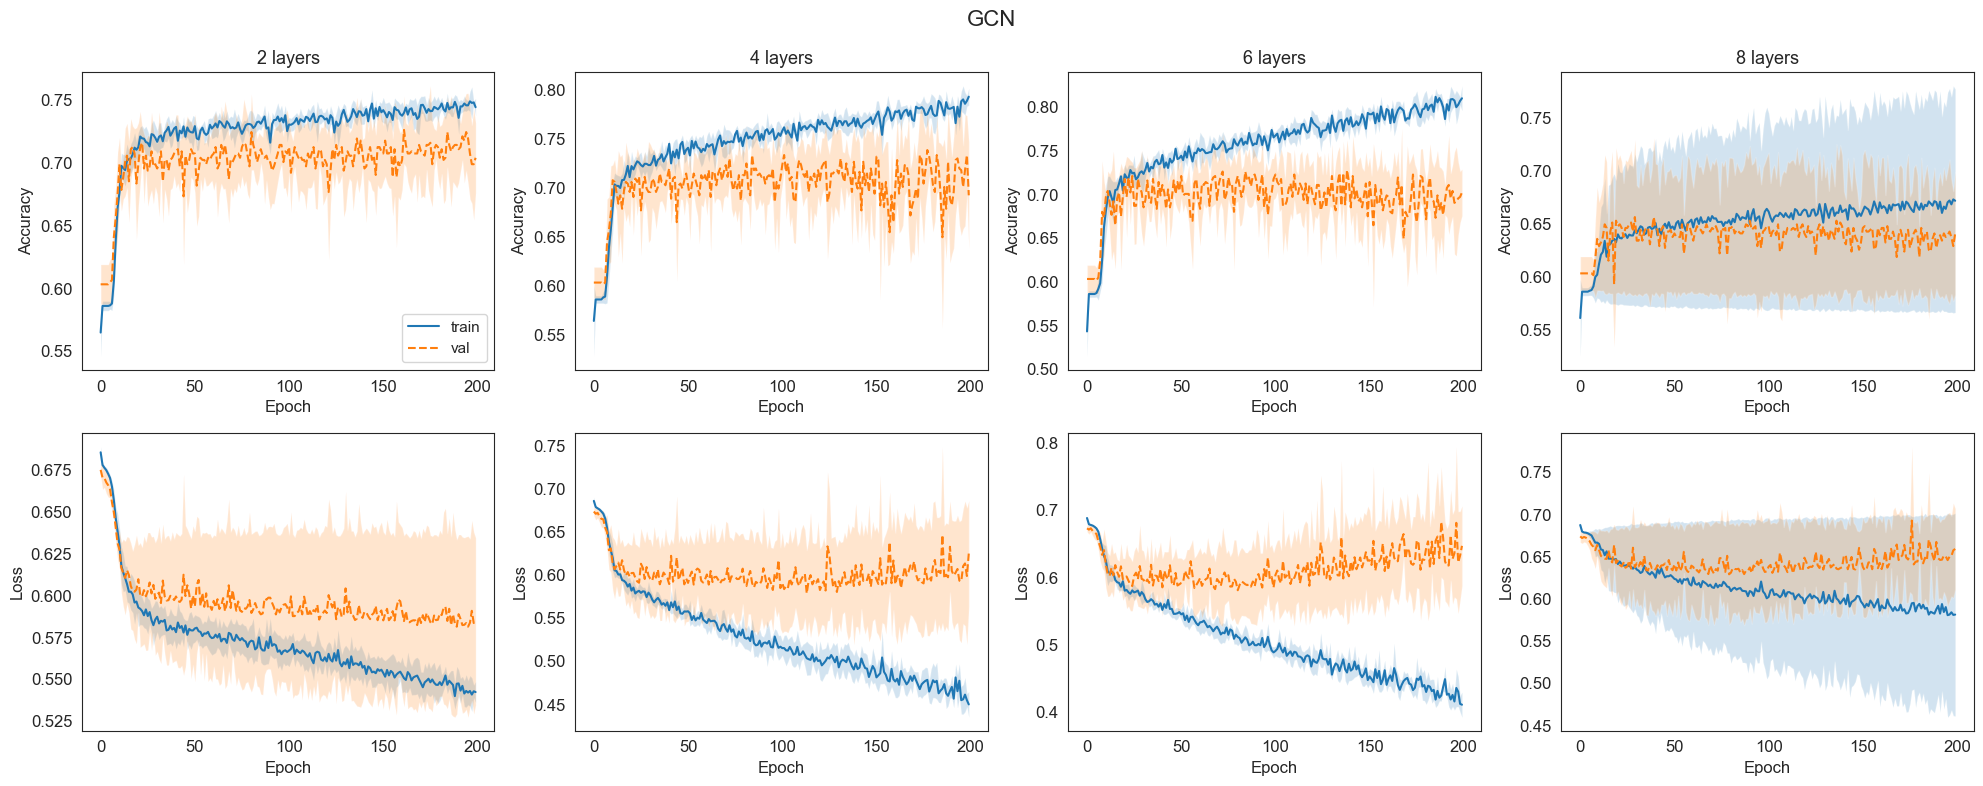

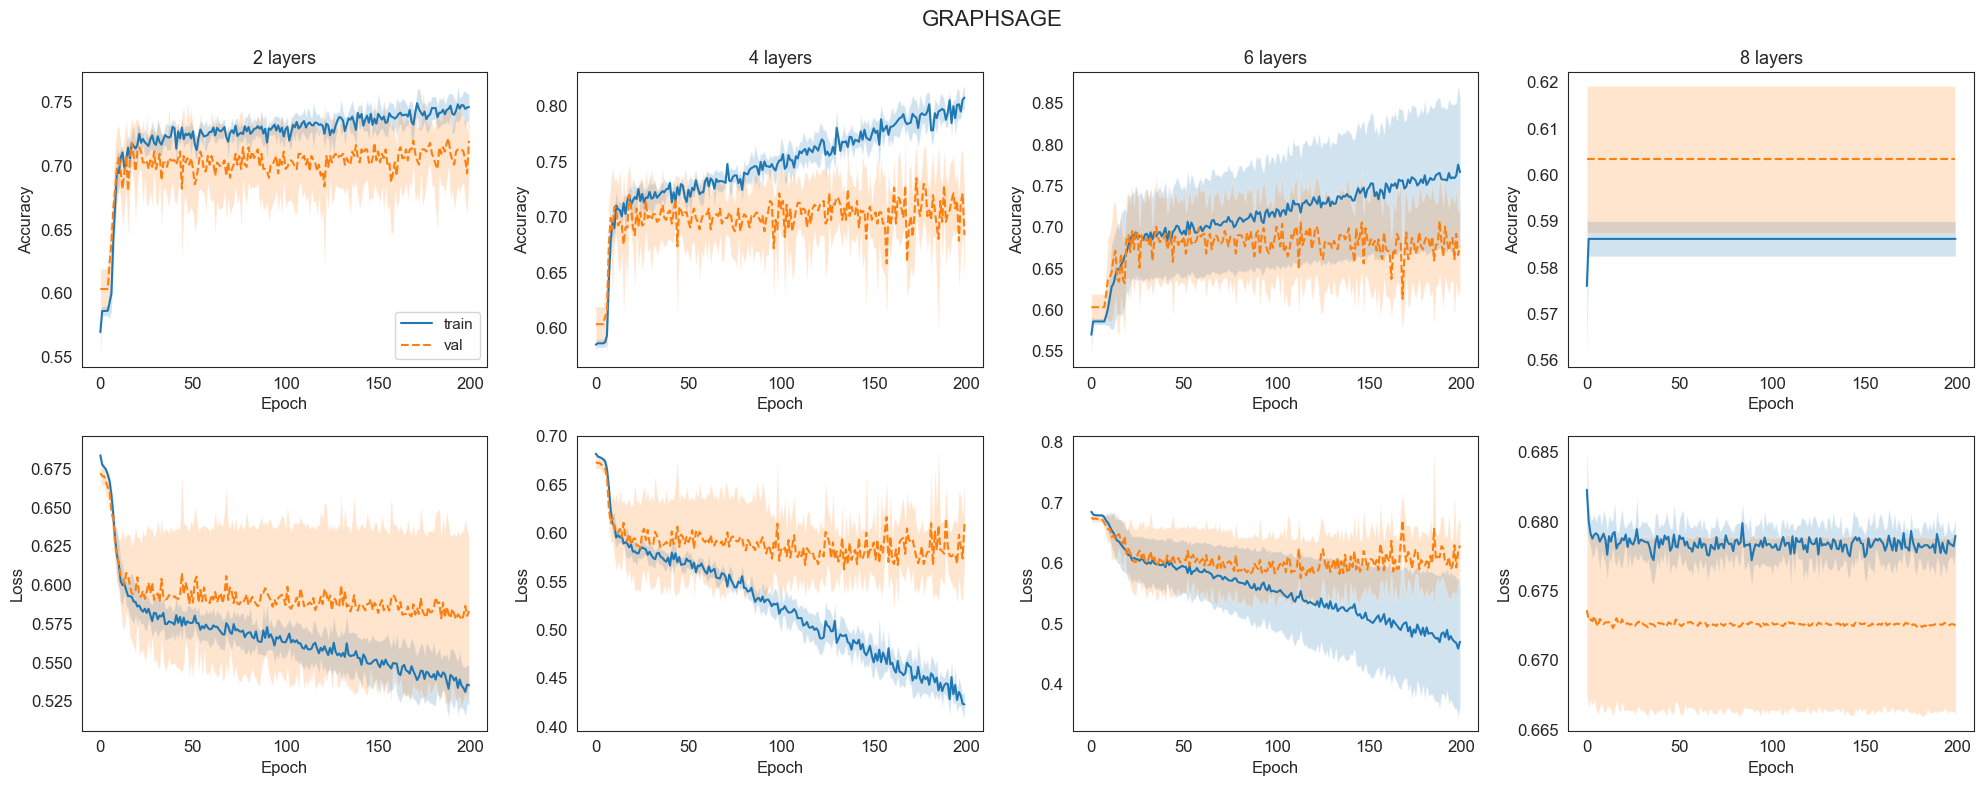

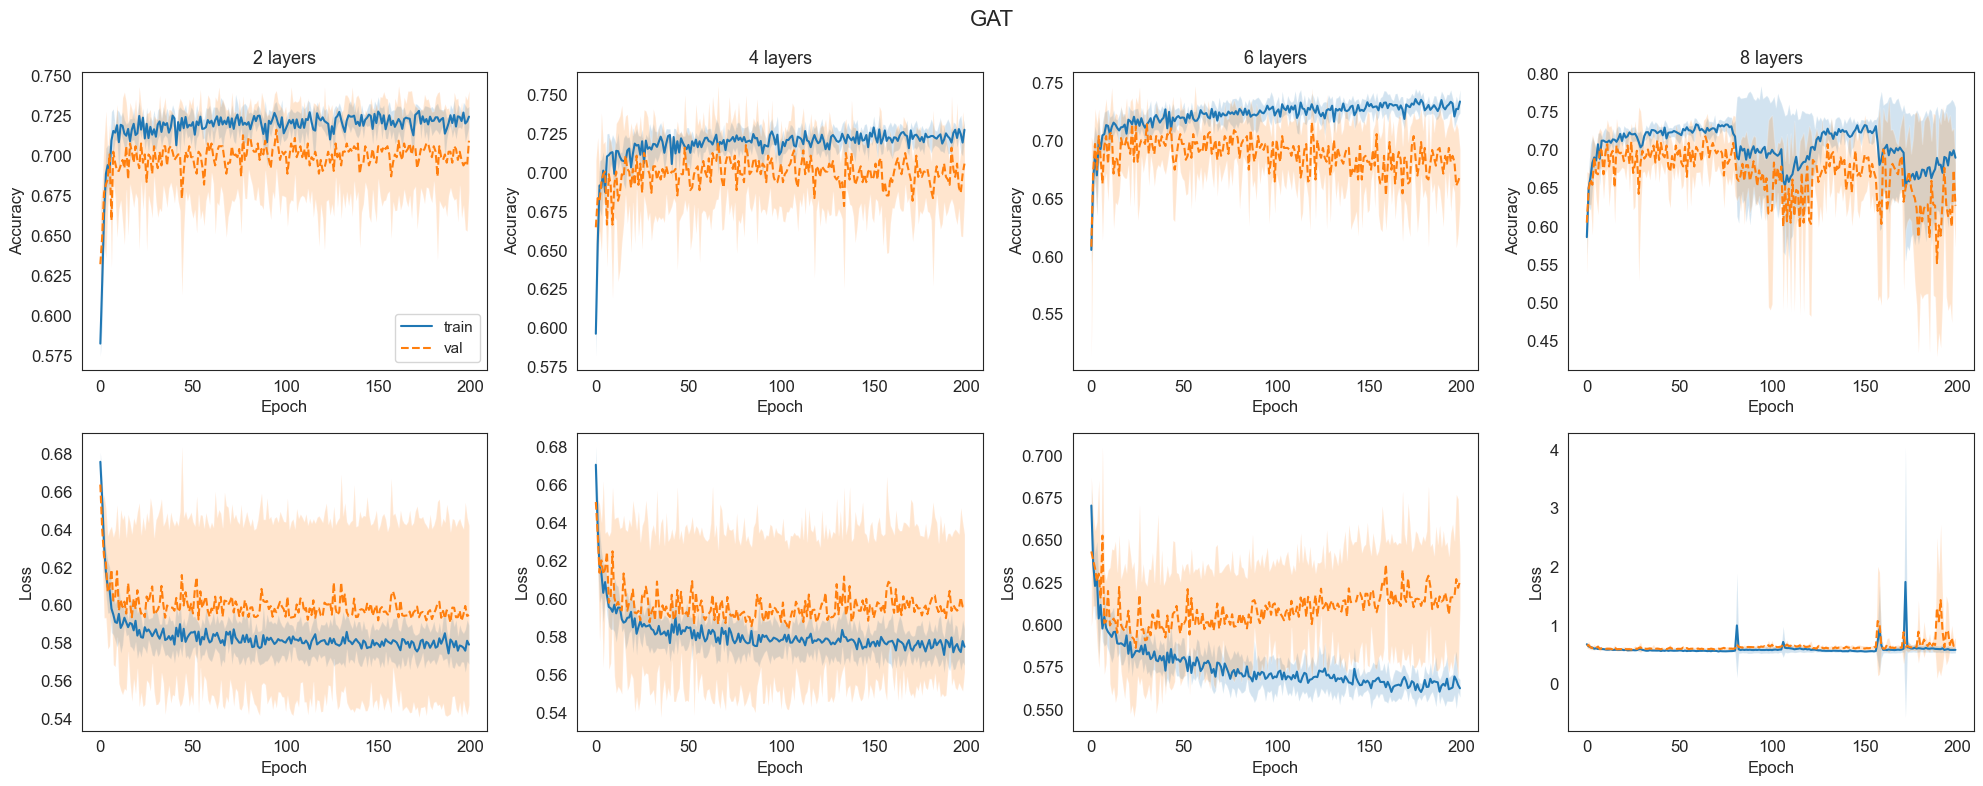

In [8]:
plot_by_model(history, "gcn")
plot_by_model(history, "graphsage")
plot_by_model(history, "gat")

In [9]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

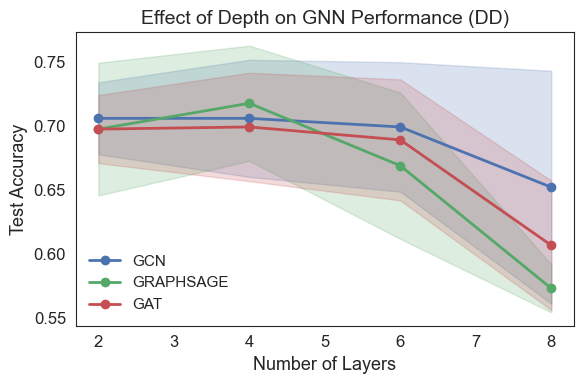

In [11]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    layers = data["layers"]
    mean = np.array(data["acc_mean"])
    std = np.array(data["acc_std"])

    plt.plot(
        layers,
        mean,
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

    # banda de variabilidad (mean ± std)
    plt.fill_between(
        layers,
        mean - std,
        mean + std,
        color=colors[model],
        alpha=0.2
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

plt.title("Effect of Depth on GNN Performance (DD)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/dd/accuracy_vs_layers.png", dpi=300)

plt.show()

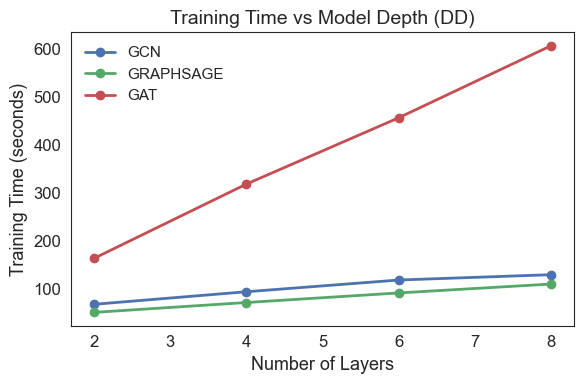

In [12]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth (DD)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/dd/time_vs_layers.png", dpi=300)

plt.show()

In [13]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "accuracy_mean": results[model]["acc_mean"][i],
            "accuracy_std": results[model]["acc_std"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../../results/tables/dd/gnn_layer_experiments.csv", index=False)

In [14]:
with open("../../results/tables/dd/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

with open("../../results/tables/dd/history.json", "w") as f:
    json.dump(history, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [4]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

print("Average nodes per graph:", np.mean(num_nodes))
print("Minimum nodes per graph:", np.min(num_nodes))
print("Maximun nodes per graph:", np.max(num_nodes))
print("Average edges per graph:", np.mean(num_edges))
print("Minimum edges per graph:", np.min(num_edges))
print("Maximum edges per graph:", np.max(num_edges))

Average nodes per graph: 284.3166383701188
Minimum nodes per graph: 30
Maximun nodes per graph: 5748
Average edges per graph: 1431.3174872665534
Minimum edges per graph: 126
Maximum edges per graph: 28534


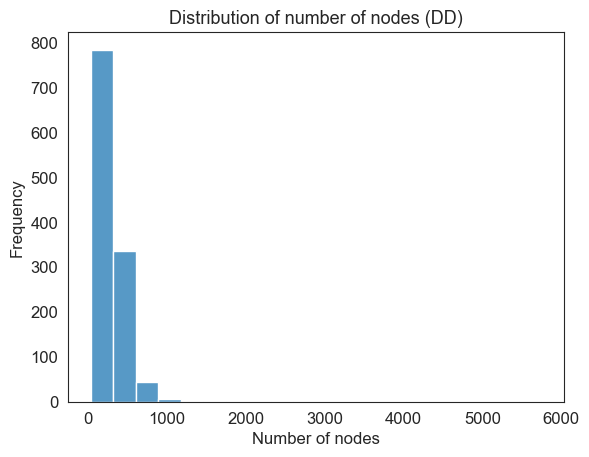

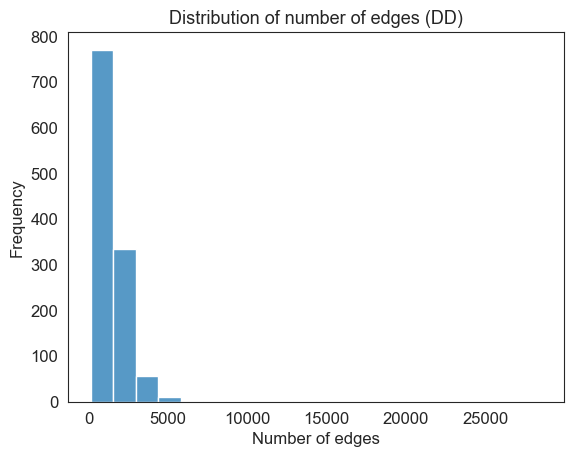

In [6]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

plt.figure()
sns.histplot(num_nodes, bins=20, kde=False)
plt.title("Distribution of number of nodes (DD)")
plt.xlabel("Number of nodes")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/dd/distribution_nodes.png",
    dpi=300
)
plt.show()

plt.figure()
sns.histplot(num_edges, bins=20, kde=False)
plt.title("Distribution of number of edges (DD)")
plt.xlabel("Number of edges")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/dd/distribution of edges.png",
    dpi=300
)
plt.show()

In [5]:
nx_graphs = []

for data in dataset:
    G = to_networkx(data, to_undirected=True)
    nx_graphs.append(G)

print("Converted graphs:", len(nx_graphs))

Converted graphs: 1178


In [6]:
from tqdm import tqdm

betweenness_values = []

for G in tqdm(nx_graphs):
    if G.number_of_edges() == 0:
        continue
        
    edge_bet = nx.edge_betweenness_centrality(G)
    betweenness_values.extend(edge_bet.values())

100%|██████████| 1178/1178 [05:26<00:00,  3.61it/s] 


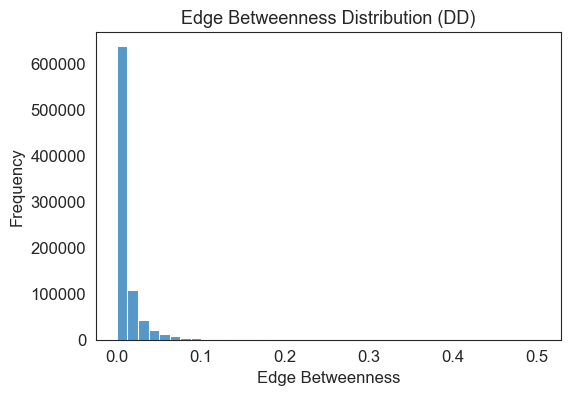

In [7]:
plt.figure(figsize=(6,4))

sns.histplot(betweenness_values, bins=40)

plt.xlabel("Edge Betweenness")
plt.ylabel("Frequency")
plt.title("Edge Betweenness Distribution (DD)")
plt.savefig(
    "../results/plots/dd/edge_betweenness.png",
    dpi=300
)

plt.show()

In [8]:
top_values = sorted(betweenness_values)[-50:]
top_values = np.sort(top_values)

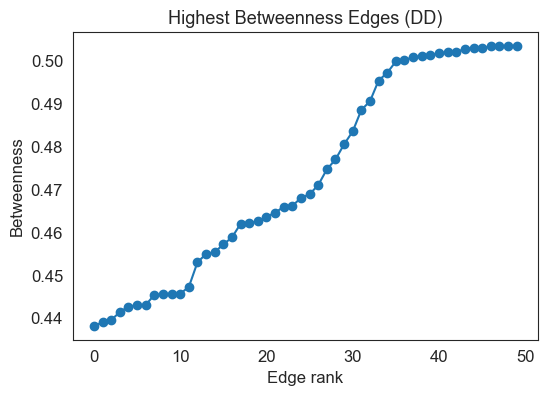

In [9]:
plt.figure(figsize=(6,4))

plt.plot(top_values, marker='o')

plt.xlabel("Edge rank")
plt.ylabel("Betweenness")
plt.title("Highest Betweenness Edges (DD)")
plt.savefig(
    "../results/plots/dd/highest_betweenness_edges.png",
    dpi=300
)
plt.show()

In [10]:
"""
Computes per-graph edge betweenness statistics.

Returns:
    dict with:
        - max: list of max betweenness per graph
        - mean: list of mean betweenness per graph
        - p95: list of 95th percentile per graph
"""

max_vals = []
mean_vals = []
p95_vals = []

for data in dataset:

    # convertir a NetworkX
    edge_index = data.edge_index.cpu().numpy()
    G = nx.Graph()
    G.add_edges_from(edge_index.T)

    # betweenness de aristas
    eb = nx.edge_betweenness_centrality(G)

    values = np.array(list(eb.values()))

    if len(values) == 0:
        continue

    max_vals.append(values.max())
    mean_vals.append(values.mean())
    p95_vals.append(np.percentile(values, 95))

stats = {
        "max": max_vals,
        "mean": mean_vals,
        "p95": p95_vals
    }

print("Avg max:", np.mean(stats["max"]))
print("Avg p95:", np.mean(stats["p95"]))

Avg max: 0.16744829113577372
Avg p95: 0.05561370652772267


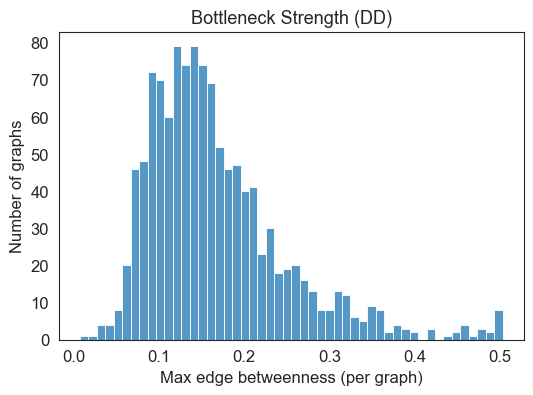

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(stats["max"], bins=50)

plt.xlabel("Max edge betweenness (per graph)")
plt.ylabel("Number of graphs")
plt.title("Bottleneck Strength (DD)")
plt.savefig(
    "../results/plots/dd/bottleneck_strength.png",
    dpi=300
)
plt.show()

In [12]:
def average_khop_growth(graphs, max_k=5):

    growth = []

    for k in range(1, max_k+1):

        sizes = []

        for G in graphs:

            if len(G.nodes()) == 0:
                continue

            node = list(G.nodes())[0]

            nodes = nx.single_source_shortest_path_length(G, node, cutoff=k)

            sizes.append(len(nodes))

        growth.append(np.mean(sizes))

    return growth

In [13]:
khop_growth = average_khop_growth(nx_graphs)

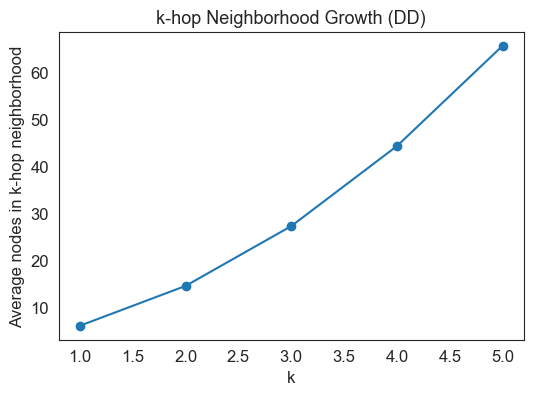

In [14]:
plt.figure(figsize=(6,4))

plt.plot(range(1,6), khop_growth, marker='o')

plt.xlabel("k")
plt.ylabel("Average nodes in k-hop neighborhood")
plt.title("k-hop Neighborhood Growth (DD)")
plt.savefig(
    "../results/plots/dd/average_nodes_in_khop.png",
    dpi=300
)
plt.show()